In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tabulate import tabulate


In [3]:
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('font', family='serif',size=12)
plt.rc('text', usetex=True)

hi

In [4]:
g=0.2
m = 1       # mass
w = 1       # supposed to be omega i.e. frequency of harmonic oscillator
hb = 1      # short for hbar

b = 10.0    # integral upper bound for Gauss-Legendre quadrature
a = -10.0   # integral lower bound for Gauss-Legendre quadrature (G-L Q)

c1 = (b-a)/2    # these two helper variables are convenient to calculate change of interval for G-L Q
c2 = (b+a)/2

samples, weights = np.polynomial.legendre.leggauss(99)      # G-L Q sample points & weights

In [5]:
#the wavefunction that solves the unperturbed Hamiltonian
def wavefunction(n, x, Omega):
    freq = np.sqrt(w**2 + Omega**2)
    xi = x * np.sqrt(m*freq/hb)
    return np.exp(-(xi**2)/2) * (m*freq /(np.pi*hb))**(1/4) * ((2**n)*sp.special.factorial(n))**(-1/2) * sp.special.eval_hermite(n, xi)


#perturbation to the Hamiltonian
def H1(x, Omega):
    return g*(x**4) - (1.0/2)*m*(Omega**2)*(x**2)

#same as trans_amp but for the perturbation alone. There is a use for this alone (see E1, E2 below) which is why I've separated it. 
def trans_amp_pert(n1, n2, x, Omega):
    return wavefunction(n1, x, Omega) * H1(x, Omega) * wavefunction(n2, x, Omega)

#zeroth order energy, i.e. energy of the unperturbed Hamiltonian
def E0(n, Omega):
    return (n*1.0 + 1.0/2)*hb*np.sqrt(w**2 + Omega**2)

# The following two functions are classic perturbation theory results, nothing special. The integrals are evaluated using Gauss-Legendre quadrature.

#first order energy correction as a result of the quartic perturbation
def E1(n, Omega):
    return c1 * np.dot(weights, trans_amp_pert(n, n, c1*samples + c2, Omega))

#second order energy correction due to quartic perturbation
def E2(n, Omega):
    E_2 = 0
    # with some more analysis you can show that you can skip every other term, but we'll keep it general
    for i in range(0, n + 5):
        if (i == n):
            continue 

        integral = c1 * np.dot(weights, trans_amp_pert(n, i, c1*samples + c2, Omega))
        E_2 += integral**2 / (E0(n, Omega) - E0(i, Omega))

    return E_2

# first order total energy. This is the function we will be minimizing to get the Omega value. 
def energy1o(n, Omega):
    return E0(n, Omega) + E1(n, Omega)

# second order total energy. We'll minimize this and show that it gives squat. 
def energy2o(n, Omega):
    return E0(n, Omega) + E1(n, Omega)  + E2(n, Omega)

# just a central difference derivative of the first order total energy. It's convenient. 
def first_derivative_1o(n, Omega):
    h=1e-5
    return (energy1o(n, Omega + h) - energy1o(n, Omega - h)) / (2*h)

# just a central difference derivative of the second order total energy. It's convenient. 
def first_derivative_2o(n, Omega):
    h=1e-5
    return (energy2o(n, Omega + h) - energy2o(n, Omega - h)) / (2*h)

In [47]:
nvals = np.arange(10)

In [53]:
Omega_1o = np.zeros_like(nvals) + 0.01
Omega_2o = np.zeros_like(nvals) + 0.01

for i in range(len(nvals)):
    Omega_1o[i] = sp.optimize.minimize(lambda x: energy1o(nvals[i], x), x0=[1.0], bounds=[(1e-6, None)]).x[0]
    Omega_2o[i] = sp.optimize.minimize(lambda x: first_derivative_2o(nvals[i], x), x0=[1.0], bounds=[(1e-6, None)]).x[0]

In [54]:
print(Omega_1o)
print(Omega_2o)

[0.93600305 1.14655845 1.35962744 1.53092447 1.67426729 1.79834029
 1.90834609 2.0076173  2.09838609 2.18231101]
[1.06901226 1.29154022 1.49277196 1.66222188 1.80563453 1.93359351
 2.04872837 2.14927536 2.24597541 2.3252767 ]


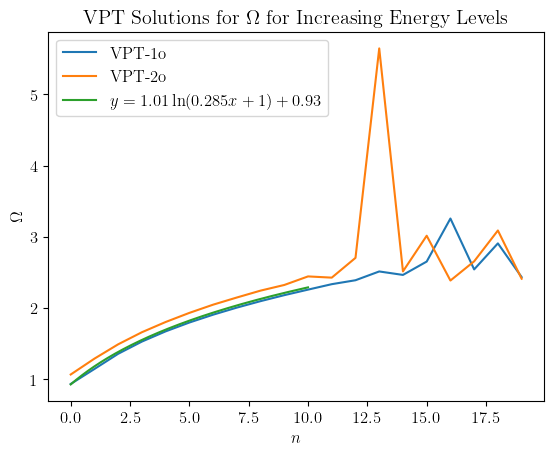

In [44]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.plot(nvals, Omega_1o, label='VPT-1o')
ax.plot(nvals, Omega_2o, label='VPT-2o')

xvals = np.arange(0, 10, 0.001)
ax.plot(xvals, 1.01*np.log(0.285*xvals + 1) + 0.93, label='$y=1.01\\ln(0.285x+1) + 0.93$')

ax.set_title('VPT Solutions for $\\Omega$ for Increasing Energy Levels')
ax.set_ylabel('$\\Omega$')
ax.set_xlabel('$n$')
ax.legend()